In [1]:
import scanpy as sc
import rapids_singlecell as rsc
import seaborn as sns
import numpy as np
import pandas as pd
from cuml.svm import SVC
from sklearn.preprocessing import LabelEncoder
from cuml.linear_model import LogisticRegression
import gcsfs
import pyarrow.dataset as ds
import os
import matplotlib.pyplot as plt

In [2]:
labels = pd.read_parquet('./embryos_labled.pq')

In [3]:
ct = pd.crosstab(labels[labels['organism'] == 'Oryctolagus cuniculus']['SRX_accession'], labels[labels['organism'] == 'Oryctolagus cuniculus']['Main_cluster_name_pred'])
ct = ct.loc[ct.sum(axis = 1) > 5000, :]
ct.var(axis = 1).sort_values()
srx= ct.var(axis = 1).sort_values().index[0]

In [4]:
fs = gcsfs.GCSFileSystem()
infile = f'gs://arc-scbasecount/2025-02-25/h5ad/GeneFull_Ex50pAS/Oryctolagus_cuniculus/{srx}.h5ad'

local_in = os.path.join("input.h5ad")


# copy from GCS
fs.get(infile, local_in)
adata =  sc.read_h5ad(local_in)
labels = labels[labels['SRX_accession'] == srx]
adata.obs = adata.obs.merge(labels,left_index=True, right_on='barcode')

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
2026-01-30 21:56:12 | [WARNING] No project ID could be determined. Consider running `gcloud config set project` or setting the GOOGLE_CLOUD_PROJECT environment variable


In [6]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.calculate_qc_metrics(adata)
rsc.pp.normalize_total(adata)
rsc.pp.log1p(adata)
rsc.pp.filter_genes(adata, min_cells = 10)
rsc.pp.filter_cells(adata, min_genes = 50)
rsc.pp.pca(adata)
rsc.pp.neighbors(adata)
rsc.tl.umap(adata)
rsc.tl.leiden(adata, resolution = 0.2)
adata.var_names = adata.var['gene_symbols']
sc.tl.dpt(zebrafish)

filtered out 8226 genes that are detected in less than 10 cells
filtered out 1 cells that have less than 50 genes expressed


/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:854: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['GOLM1', 'ENSOCUG00000031223', 'ENSOCUG00000036469', 'ENSOCUG00000036117', 'JHY']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [14]:
adata.uns["iroot"] = np.flatnonzero(adata.obs['Main_cluster_name_pred'] == "Erythroblasts")[0]
sc.tl.dpt(adata)

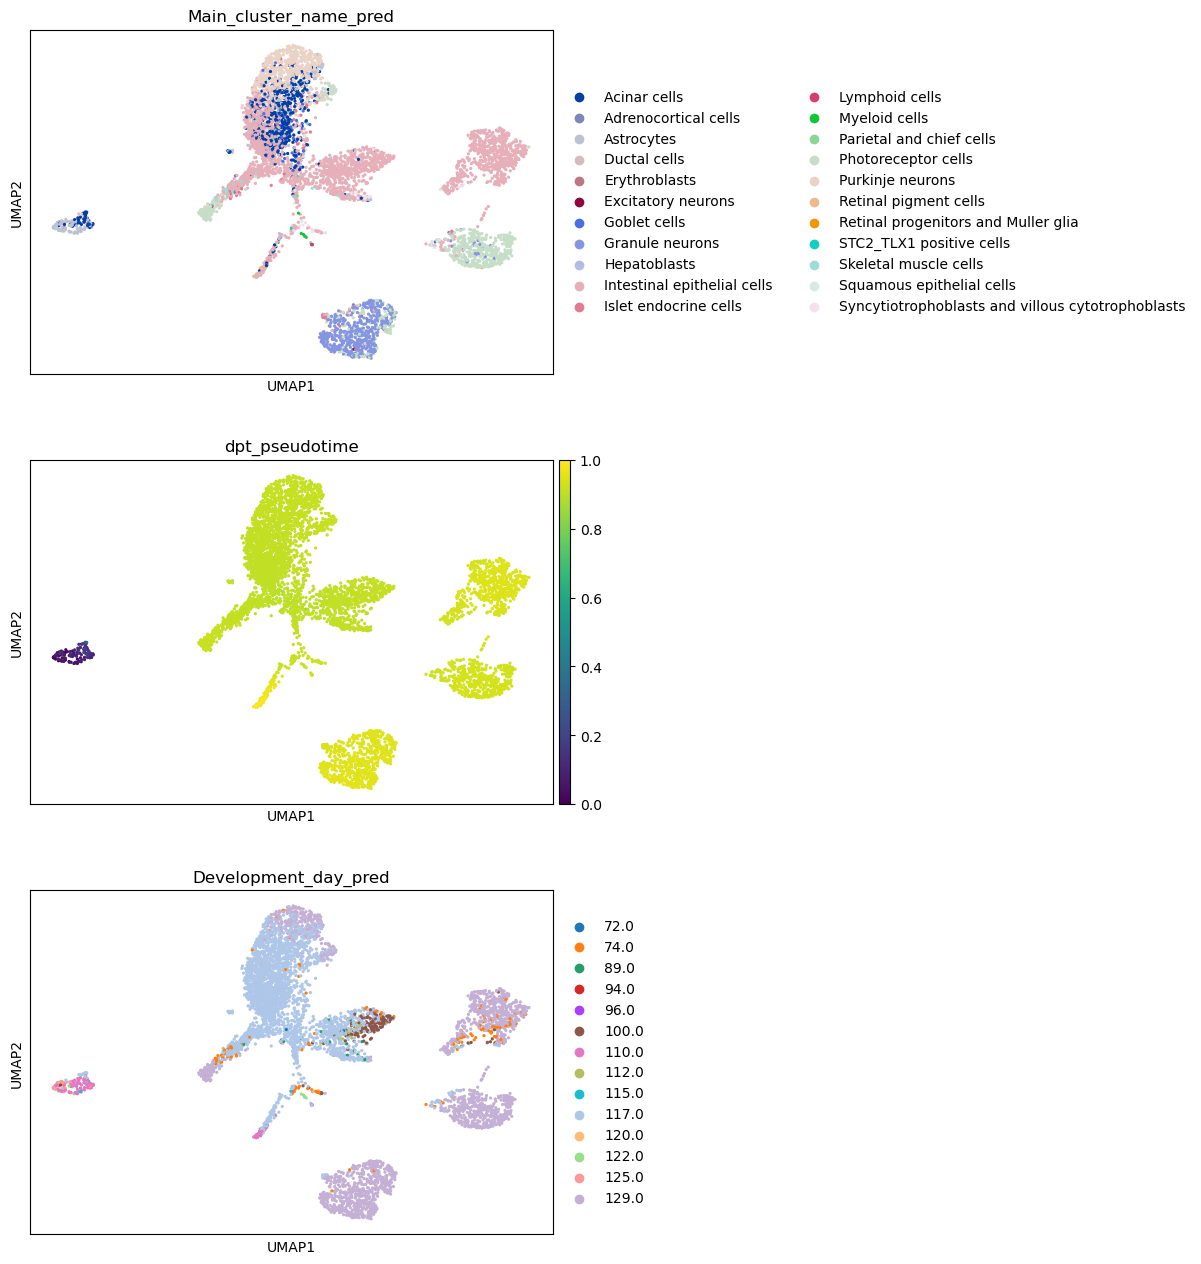

In [15]:
sc.pl.umap(adata, color =['Main_cluster_name_pred', 'dpt_pseudotime','Development_day_pred'], ncols=1)

/tmp/ipykernel_279525/3562773928.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Main_cluster_name_pred")["dpt_pseudotime"]


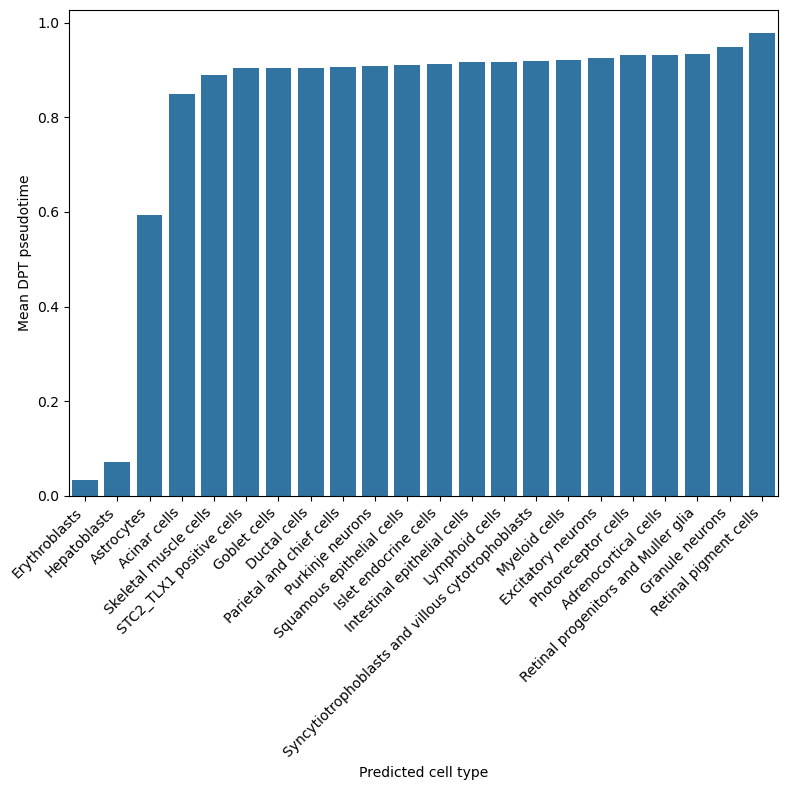

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute means and sort
means = (
    adata.obs
    .groupby("Main_cluster_name_pred")["dpt_pseudotime"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 8))

sns.barplot(
    x=means.index,
    y=means.values,
    order=means.index   # <-- enforce order
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean DPT pseudotime")
plt.xlabel("Predicted cell type")
plt.tight_layout()
plt.savefig('Rabit_cell_types_predicted_time.png')
plt.show()


In [24]:
adata = adata.copy()

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [26]:
adata = adata[~adata.obs['Main_cluster_name_pred'].isin(['Retinal progenitors and Muller glia', 'Ductal cells'])]
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(adata, groupby='Main_cluster_name_pred', reference='Syncytiotrophoblasts and villous cytotrophoblasts')
degs = sc.get.rank_genes_groups_df(adata, None)
degs = degs[degs['group'] =='Intestinal epithelial cells' ].sort_values('pvals')

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/scanpy/get/get.py:462: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = val
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not 

In [30]:
sub = adata[adata.obs['Main_cluster_name_pred'] == 'Syncytiotrophoblasts and villous cytotrophoblasts'].copy()
qc = sc.pp.calculate_qc_metrics(sub)
bad_genes_list = list(qc[1][qc[1]['n_cells_by_counts'] < 2].index)
sub = adata[adata.obs['Main_cluster_name_pred'] == 'Intestinal epithelial cells'].copy()
qc = sc.pp.calculate_qc_metrics(sub)
bad_genes = list(qc[1][qc[1]['n_cells_by_counts'] < 2].index)
bad_genes_list.extend(bad_genes)

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [28]:
degs = degs[~degs['names'].isin(bad_genes_list)]

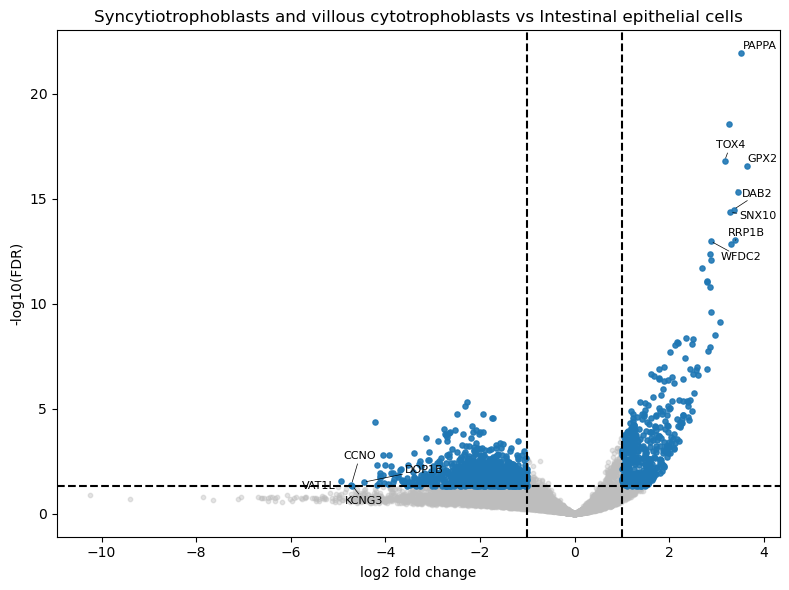

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fdr_thresh = 0.05
lfc_thresh = 1.0
label_n = 10

df = degs.copy()
df["log10_fdr"] = -np.log10(df["pvals"].clip(lower=1e-300))

up = (df["pvals"] < fdr_thresh) & (df["logfoldchanges"] > lfc_thresh)
down = (df["pvals"] < fdr_thresh) & (df["logfoldchanges"] < -lfc_thresh)
ns = ~(up | down)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df.loc[ns, "logfoldchanges"], df.loc[ns, "log10_fdr"],
           s=10, color="#BDBDBD", alpha=0.4)

ax.scatter(df.loc[up, "logfoldchanges"], df.loc[up, "log10_fdr"],
           s=14, color="#1F77B4", alpha=0.9)

ax.scatter(df.loc[down, "logfoldchanges"], df.loc[down, "log10_fdr"],
           s=14, color="#1F77B4", alpha=0.9)

# threshold lines
ax.axhline(-np.log10(fdr_thresh), linestyle="--", color="black")
ax.axvline(lfc_thresh, linestyle="--", color="black")
ax.axvline(-lfc_thresh, linestyle="--", color="black")

# labels
label_df = df[up | down].sort_values("pvals_adj").head(label_n)

label_df = pd.concat([label_df, df[down].sort_values("logfoldchanges").head(5)])
label_df.loc[label_df['names'].str.startswith('ENSOC'), 'names'] = None

texts = [
    ax.text(r["logfoldchanges"], r["log10_fdr"], r["names"], fontsize=8)
    for _, r in label_df.iterrows()
]

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5), force_text=(1,2))
ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Syncytiotrophoblasts and villous cytotrophoblasts vs Intestinal epithelial cells")
plt.tight_layout()
plt.savefig('Intestine_volcano.png')
plt.savefig('Intestine_volcano.pdf')
plt.show()


In [33]:
degs[degs['logfoldchanges'] <0 ].sort_values('pvals').head(30)

,group,names,scores,logfoldchanges,pvals,pvals_adj
163034,Intestinal epithelial cells,MAP4K4,-5.349050,-2.265450,0.000005,0.000085
163033,Intestinal epithelial cells,RBFOX2,-5.226891,-2.306807,0.000007,0.000119
163032,Intestinal epithelial cells,RALGPS2,-4.949932,-2.495294,0.000017,0.000250
163031,Intestinal epithelial cells,PUM1,-4.930646,-1.936730,0.000018,0.000259
163030,Intestinal epithelial cells,VGLL4,-4.790255,-1.741243,0.000027,0.000371
163029,Intestinal epithelial cells,IGF2BP3,-4.774692,-1.724880,0.000029,0.000386
163028,Intestinal epithelial cells,ENSOCUG00000002662,-4.661327,-4.219413,0.000042,0.000530
163027,Intestinal epithelial cells,GSK3B,-4.502143,-2.175402,0.000067,0.000792
163026,Intestinal epithelial cells,CA4,-4.386196,-2.756800,0.000095,0.001053
163025,Intestinal epithelial cells,FNBP1L,-4.369429,-2.078845,0.000099,0.001093
